In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D
import matplotlib.cm as cm

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

# Collect file lists
emul_files = sorted(glob.glob("../plotting_data/corrdiff/30-39/per_file_id011/*.npy"))
orig_files = sorted(glob.glob("../plotting_data/orig_RCM_30-39/id011/*.npy"))
emul_files_50 = sorted(glob.glob("../plotting_data/corrdiff/50samples/*.npy"))

/tmp/ipykernel_223924/3835364798.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", n_models)  # For individual colors


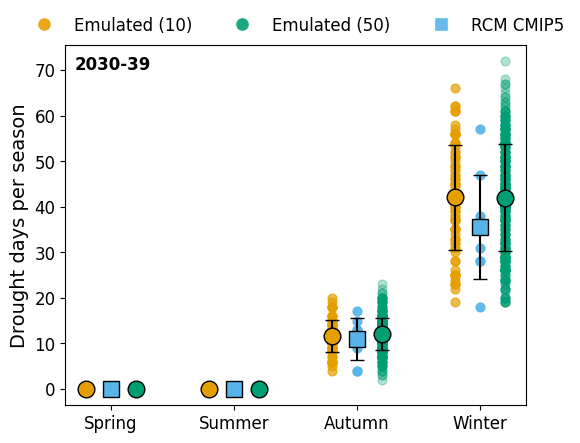

In [ ]:
# Collect file lists
seed = 42
rng = np.random.default_rng(seed)

n_models = len(emul_files)
colors = cm.get_cmap("tab10", n_models)  # For individual colors

emul_color = "#E69F00"
orig_color = "#56B4E9"
gcm_color = "#009E73"

fig, axes = plt.subplots(1, 1, figsize=(6, 4.5))

all_emul_10 = []
all_emul_50 = []
all_orig = []
offset = 0.2

new_order = [1, 2, 0, 3]
# --- Emulated and Original ---
for emul_file, orig_file, emul_50 in zip(emul_files, orig_files, emul_files_50):

    # Emulated 50
    season_counts_np = np.load(emul_50, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]
    season_counts_np = season_counts_np[:, new_order]
    all_emul_50.append(season_counts_np)

    for e in range(season_counts_np.shape[0]):
        x = np.arange(season_counts_np.shape[1]) + offset
        plt.scatter(x, season_counts_np[e, :], color=gcm_color, alpha=0.3, s=40)

    # Emulated 10
    season_counts_np = np.load(emul_file, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]
    season_counts_np = season_counts_np[:, new_order]
    all_emul_10.append(season_counts_np)

    for e in range(season_counts_np.shape[0]):
        x = np.arange(season_counts_np.shape[1]) - offset
        plt.scatter(x, season_counts_np[e, :], color=emul_color, alpha=0.7, s=40)

    # Original
    season_counts_np = np.load(orig_file, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]
    season_counts_np = season_counts_np[new_order]
    all_orig.append(season_counts_np)

    x = np.arange(len(season_counts_np))
    plt.scatter(x, season_counts_np, color=orig_color, s=40, alpha=0.9)


# --- Compute means and std ---
emul10_stack = np.vstack(all_emul_10)
emul50_stack = np.vstack(all_emul_50)
orig_stack = np.vstack(all_orig)

emul10_mean, emul10_std = emul10_stack.mean(0), emul10_stack.std(0)
emul50_mean, emul50_std = emul50_stack.mean(0), emul50_stack.std(0)
orig_mean, orig_std = orig_stack.mean(0), orig_stack.std(0)

x_vals = np.arange(emul10_stack.shape[1])

# Errorbars
plt.errorbar(
    x_vals - offset,
    emul10_mean,
    yerr=emul10_std,
    fmt="o",
    color=emul_color,
    ecolor="black",
    markeredgecolor="black",
    markersize=12,
    label="Emulated (10) ± std",
    capsize=5,
)

plt.errorbar(
    x_vals + offset,
    emul50_mean,
    yerr=emul50_std,
    fmt="o",
    color=gcm_color,
    ecolor="black",
    markeredgecolor="black",
    markersize=12,
    label="Emulated (50) ± std",
    capsize=5,
)

plt.errorbar(
    x_vals,
    orig_mean,
    yerr=orig_std,
    fmt="s",
    color=orig_color,
    markeredgecolor="black",
    ecolor="black",
    markersize=12,
    label="Original ± std",
    capsize=5,
)

season_names = ["Spring", "Summer", "Autumn", "Winter"]
plt.xticks(np.arange(4), season_names)
plt.ylabel("Drought days per season")

# Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color,
        markersize=10,
        alpha=0.9,
        label="Emulated (10)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=gcm_color,
        markersize=10,
        alpha=0.9,
        label="Emulated (50)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=orig_color,
        markersize=10,
        alpha=0.9,
        label="RCM CMIP5",
    ),
]
plt.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
)
axes.text(
    0.02,
    0.97,
    "2030-39",
    transform=axes.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)

plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.savefig("../plots/0082_more_samples.pdf")
plt.show()